In [1]:
# Imports

import os

import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from sqlalchemy import URL, create_engine

In [2]:
# Load

load_dotenv()

url = URL.create(
    "postgresql+psycopg",
    username=os.environ["PGUSER"],
    password=os.getenv("PGPASSWORD") or None,
    host=os.environ["PGHOST"],
    port=int(os.environ["PGPORT"]),
    database=os.environ["PGDATABASE"],
)

engine = create_engine(url)

query = """
WITH daily_table AS (
    SELECT 
        (time AT TIME ZONE 'America/Edmonton')::date AS day, SUM(precipitation) AS total_precipitation
    FROM practice_009.weather_hourly
    WHERE time >= TIMESTAMPTZ '2025-01-01 00:00:00 America/Edmonton'
      AND time <  TIMESTAMPTZ '2026-01-01 00:00:00 America/Edmonton'
    GROUP BY (time AT TIME ZONE 'America/Edmonton')::date
)

SELECT
    TO_CHAR(DATE_TRUNC('month', day), 'Mon') AS month, COUNT(*) FILTER (WHERE total_precipitation >= 1) AS precipitation_days
FROM daily_table
GROUP BY DATE_TRUNC('month', day)
ORDER BY DATE_TRUNC('month', day);
"""

df = pd.read_sql_query(query, engine)
df

,month,precipitation_days
0,Jan,2
1,Feb,3
2,Mar,4
3,Apr,11
4,May,13
5,Jun,9
6,Jul,17
7,Aug,8
8,Sep,3
9,Oct,4


In [3]:
# Inspect

# Structure
print(df["month"].iloc[0], "to", df["month"].iloc[-1], "\n")
print("Shape:", df.shape, "\n")
print("Dtypes:")
print(df.dtypes, "\n")

# Missingness
print("Any Nulls:", df.isna().any().any(), "\n")

# Duplicates
print("Duplicate Rows:", df.duplicated().any(), "\n")

Jan to Dec 

Shape: (12, 2) 

Dtypes:
month                   str
precipitation_days    int64
dtype: object 

Any Nulls: False 

Duplicate Rows: False 



In [4]:
df[["precipitation_days"]].describe().T

,count,mean,std,min,25%,50%,75%,max
precipitation_days,12.0,7.583333,4.640892,2.0,3.75,7.5,10.25,17.0


In [5]:
# Clean
# No clean required after inspection.

In [6]:
# Validate

assert len(df) == 12
assert df["month"].nunique() == 12
assert df["precipitation_days"].between(0, 31).all()

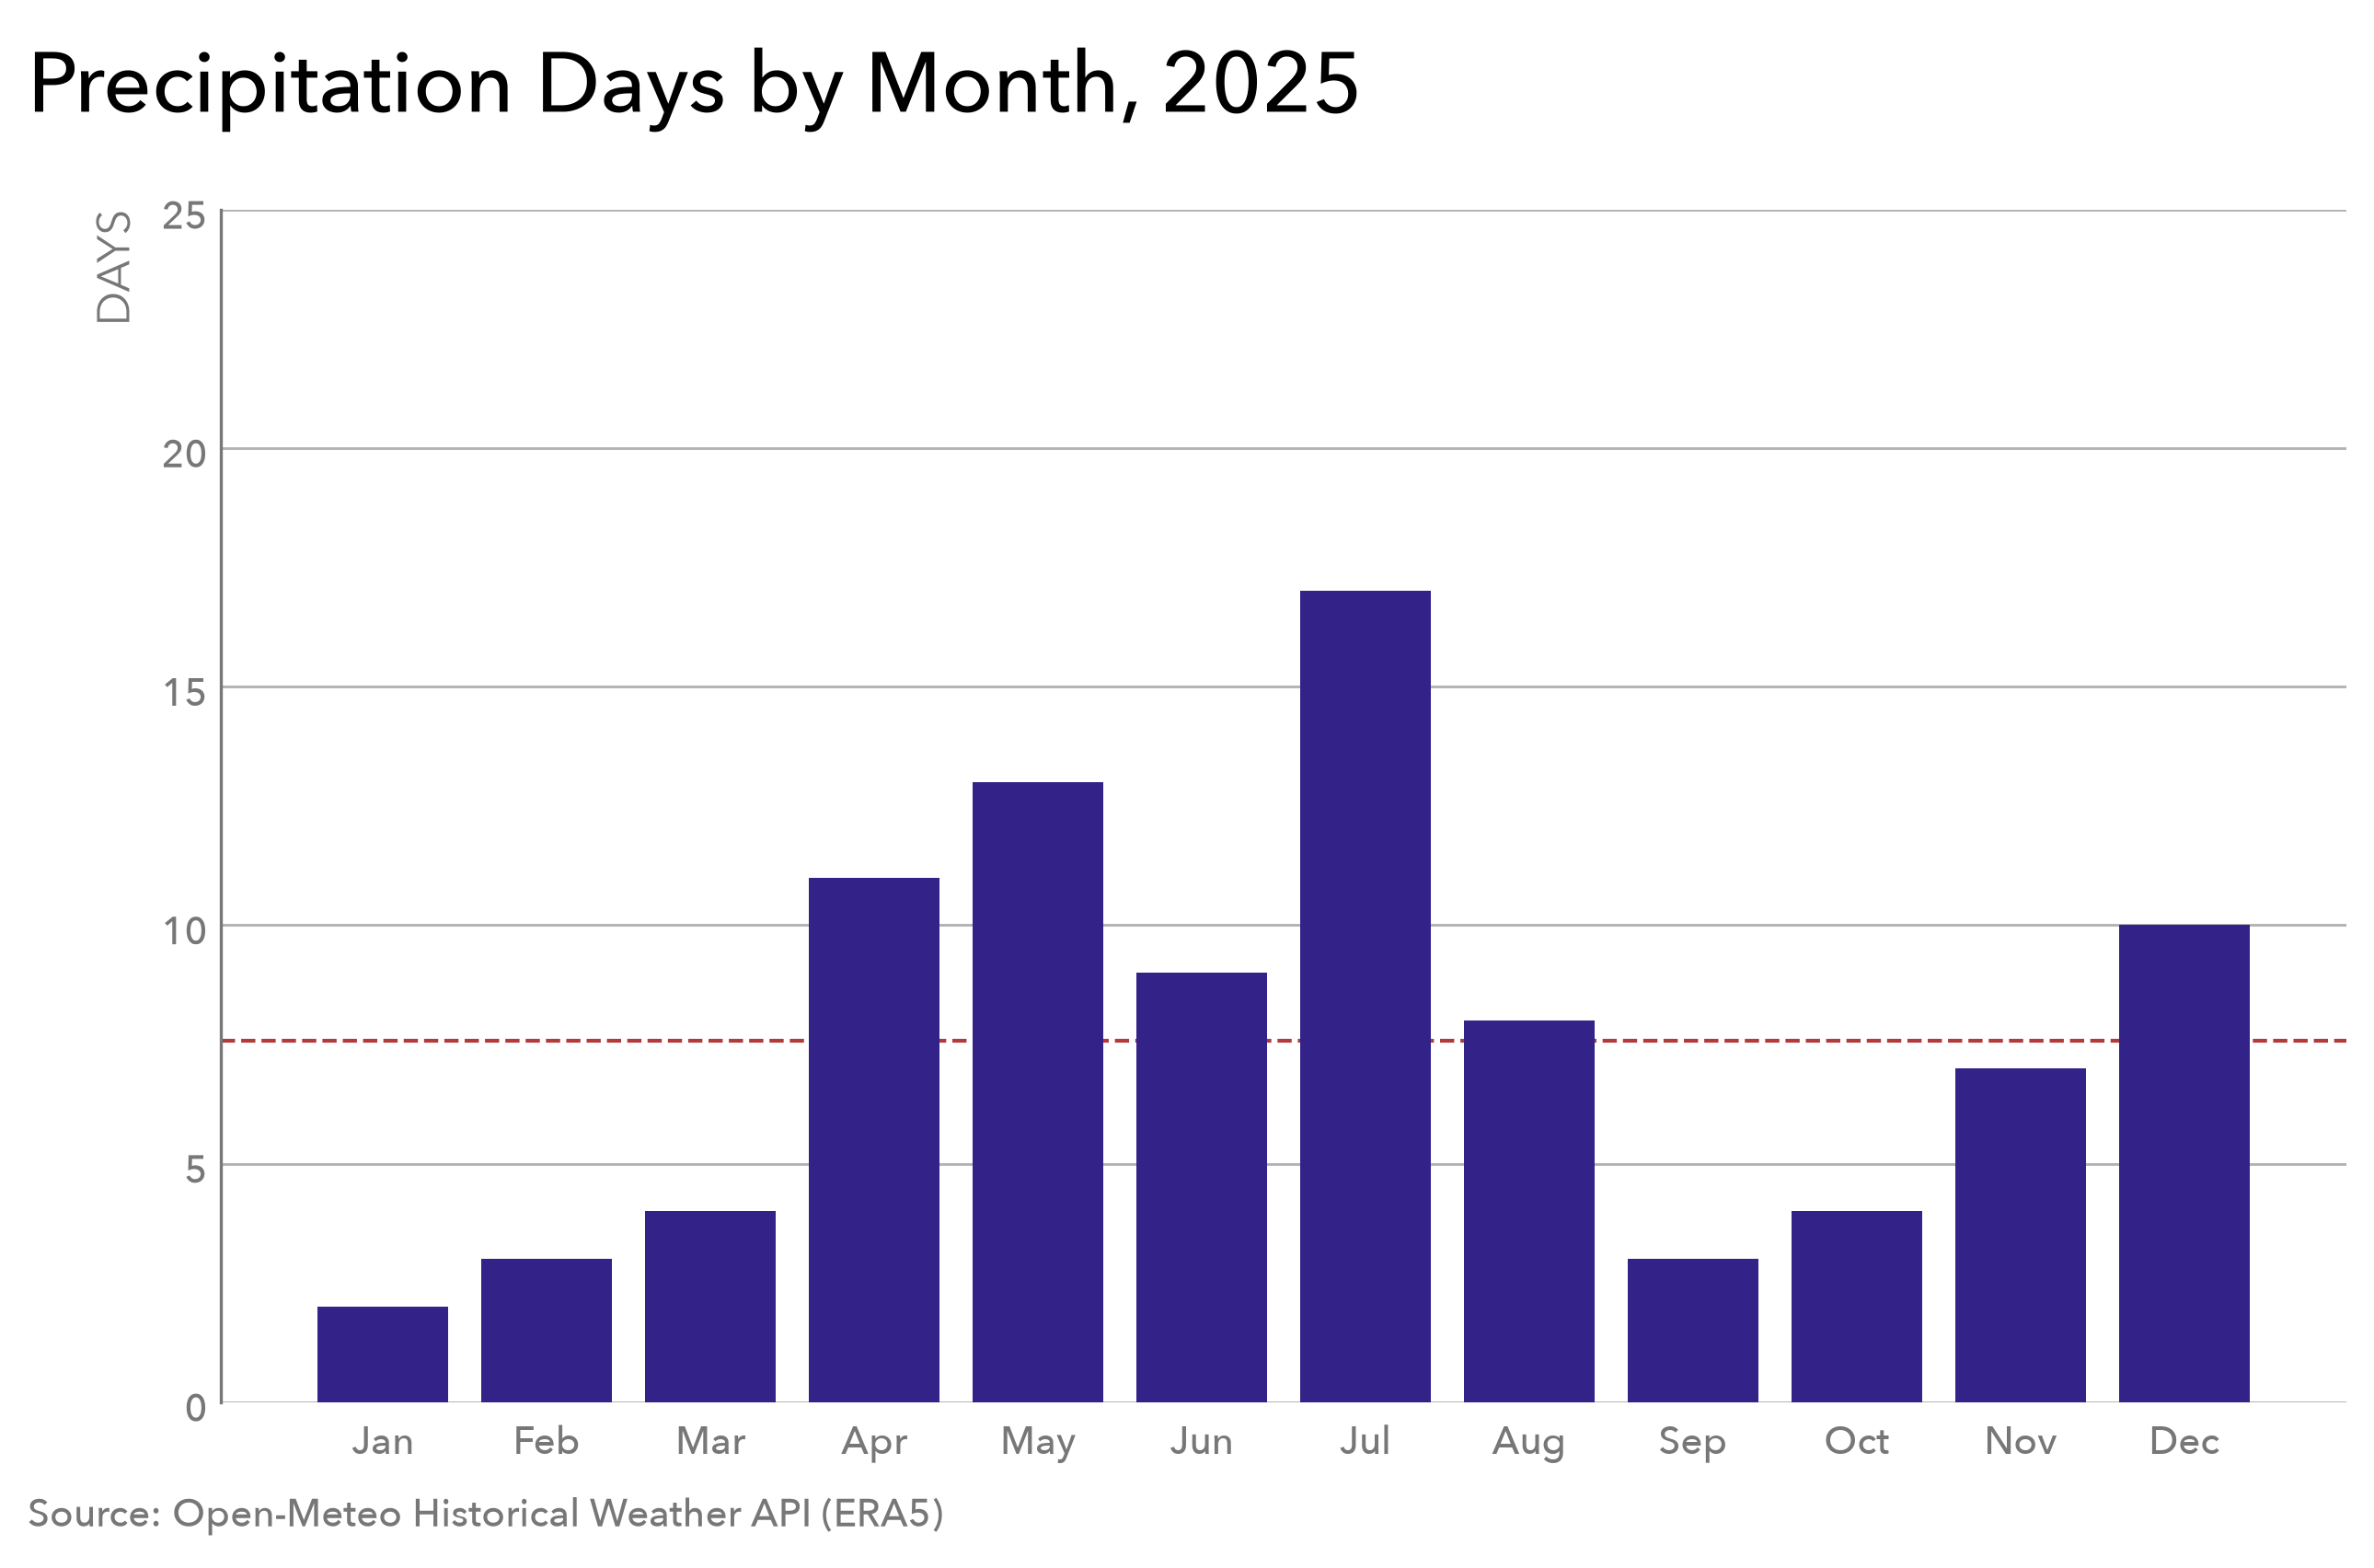

In [7]:
# Visualize

# Figure

plt.rcParams["font.family"] = "Avenir Next"
plt.rcParams["font.weight"] = 500

fig, ax = plt.subplots(figsize = (10, 6), dpi = 300)

fig.subplots_adjust(
    left = 0.13,
    right = 0.90,
    top = 0.83,
    bottom = 0.11
)

STRUCTURE = "#777777"
GRID = "#B3B3B3"
BAR_COLOUR = "#332288"
EMPHASIS = "#B33A3A"

# Plot

bars = ax.bar(df["month"], df["precipitation_days"], width = 0.8, color = BAR_COLOUR)

# Emphasis

MONTHLY_MEAN = df["precipitation_days"].mean()

ax.axhline(MONTHLY_MEAN, color = EMPHASIS, linewidth = 1, linestyle = "--", zorder = 0)

# Scale & Axes

ax.set_ylim(0, 25)

ax.set_ylabel("DAYS", loc = "top", fontsize = 12, fontweight = 400, color = STRUCTURE)

# Ticks

ax.set_yticks([0, 5, 10, 15, 20, 25])

ax.tick_params(axis = "x", labelsize = 10, length = 0, labelcolor = STRUCTURE)
ax.tick_params(axis = "y", labelsize = 10, length = 0, labelcolor = STRUCTURE)

# Styling

ax.spines[["top", "right", "bottom"]].set_visible(False)
ax.spines["left"].set_color(STRUCTURE)
ax.spines["left"].set_linewidth(0.8)

ax.set_axisbelow(True)
ax.grid(axis = "y",which = "major", color = GRID, linewidth=0.7)

# Composition

fig.suptitle("Precipitation Days by Month, 2025", x = 0.06, y = 0.94, ha = "left", va = "top", fontweight = 500, fontsize = 22)

fig.text(0.06, 0.035, "Source: Open-Meteo Historical Weather API (ERA5)", fontsize = 10, color = STRUCTURE)

# Output
fig.savefig("outputs/precipitation-days-by-month-2025.svg", bbox_inches = "tight", pad_inches = 0.1)
plt.show()